# Unit 8: Convolutional Neural Networks (CNNs)

This tutorial is based on:

https://www.tensorflow.org/tutorials/images/cnn

We shall reproduce and add to that tutorial which uses the the CIFAR10 dataset

Adaptions are permitted as specified by:
https://creativecommons.org/licenses/by/4.0/

# Task 0

Run the Tensorflow cnn tutorial in Google Colaboratory. Save the output as a separate file. Then return here.


Additionally, the tutorials:

https://towardsdatascience.com/visualizing-intermediate-activation-in-convolutional-neural-networks-with-keras-260b36d60d0

and 

https://machinelearningmastery.com/how-to-visualize-filters-and-feature-maps-in-convolutional-neural-networks/

may help you with some of the tasks in this notebook. 


This tutorial demonstrates training a simple [Convolutional Neural Network](https://developers.google.com/machine-learning/glossary/#convolutional_neural_network) (CNN) to classify [CIFAR images](https://www.cs.toronto.edu/~kriz/cifar.html). Because this tutorial uses the [Keras Sequential API](https://www.tensorflow.org/guide/keras/overview), creating and training your model will take just a few lines of code.


### Import TensorFlow

In [1]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

### Import Numpy

In [2]:
import numpy as np

### Download and prepare the CIFAR10 dataset


The CIFAR10 dataset contains 60,000 color images in 10 classes, with 6,000 images in each class. The dataset is divided into 50,000 training images and 10,000 testing images. The classes are mutually exclusive and there is no overlap between them.

In [3]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [4]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

# Task 1 
Verify the sizes of the test and training sets.

In [5]:
print("Training set - Images shape:", train_images.shape)
print("Training set - Labels shape:", train_labels.shape)
print("Test set - Images shape:", test_images.shape)
print("Test set - Labels shape:", test_labels.shape)

Training set - Images shape: (50000, 32, 32, 3)
Training set - Labels shape: (50000, 1)
Test set - Images shape: (10000, 32, 32, 3)
Test set - Labels shape: (10000, 1)


### Verify the data

To verify that the dataset looks correct, let's plot the first 25 images from the training set and display the class name below each image:


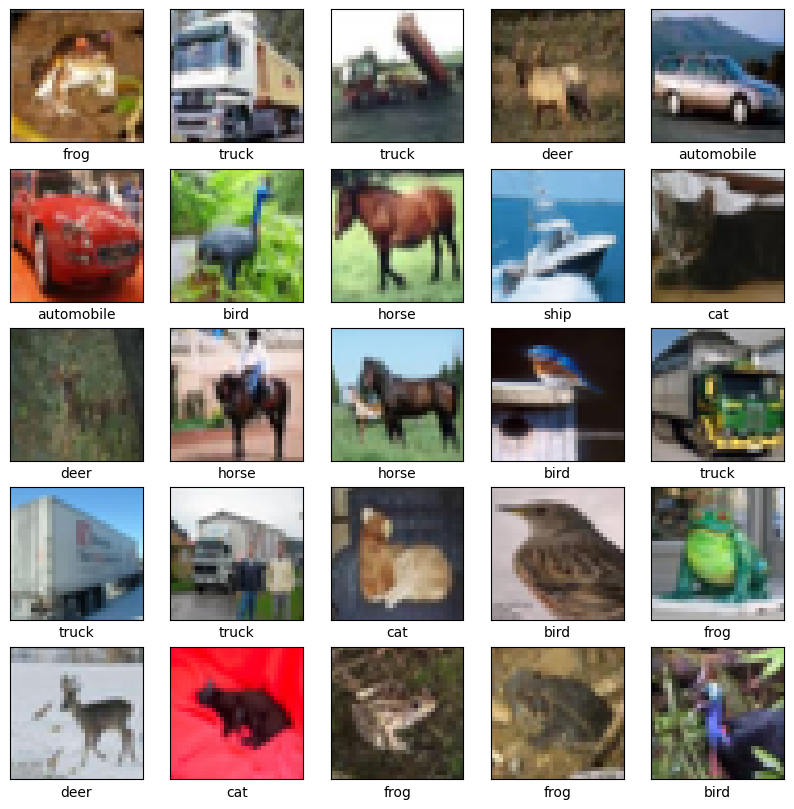

In [6]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays, 
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

# Task 2
Choose an element of the test set, plot it, and place its class label on the x-axis.

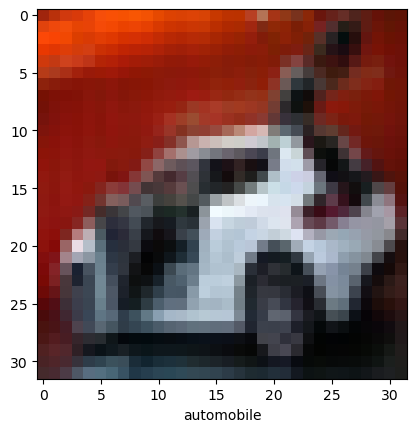

In [7]:
# Choose the index of the specific image you want to plot
index = 6

# Plot the image
plt.imshow(test_images[index])
plt.xlabel(class_names[test_labels[index][0]])

# Show the plot
plt.show()

# Task 3

Create the same cnn to that of https://www.tensorflow.org/tutorials/images/cnn, but add dropout renormalization with a rate of 50% in a few places, e.g.  after each max-pooling layers and also between the two dense layers of model.
https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dropout

Display a summary of your neural network, showing the architecture.

In [8]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.5))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.5))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))

In [9]:
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10))


In [10]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 15, 15, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 6, 6, 64)          0

# Task 4
### Compile and train the model


Keep track of the best set of weights using the ModelCheckpoint:

https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ModelCheckpoint

Monitor accuracy on the valudation set, and only save the best weights.
Save the checkpoint in an hdf5 file.

You may refer to the following tutorials to help you with this task:

https://www.tensorflow.org/tutorials/keras/save_and_load

https://towardsdatascience.com/visualizing-intermediate-activation-in-convolutional-neural-networks-with-keras-260b36d60d0

First compile the model as before

In [11]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [12]:
checkpoint_filepath = "best_weights.hdf5"
checkpointer_callbacks = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',verbose =1 ,
    save_best_only=True)

In [13]:
# Train the model with the ModelCheckpoint callback
history = model.fit(train_images, train_labels, epochs=3,
                    validation_data=(test_images, test_labels),
                    callbacks=[checkpointer_callbacks])


Epoch 1/3


1563/1563 [==============================] - ETA: 0s - loss: 1.8938 - accuracy: 0.2865
Epoch 1: val_accuracy improved from -inf to 0.44940, saving model to best_weights.hdf5
1563/1563 [==============================] - 25s 15ms/step - loss: 1.8938 - accuracy: 0.2865 - val_loss: 1.5459 - val_accuracy: 0.4494
Epoch 2/3
1560/1563 [============================>.] - ETA: 0s - loss: 1.5872 - accuracy: 0.4221
Epoch 2: val_accuracy improved from 0.44940 to 0.47930, saving model to best_weights.hdf5
1563/1563 [==============================] - 24s 15ms/step - loss: 1.5871 - accuracy: 0.4221 - val_loss: 1.4898 - val_accuracy: 0.4793
Epoch 3/3
1562/1563 [============================>.] - ETA: 0s - loss: 1.5034 - accuracy: 0.4561
Epoch 3: val_accuracy improved from 0.47930 to 0.50930, saving model to best_weights.hdf5
1563/1563 [==============================] - 26s 17ms/step - loss: 1.5034 - accuracy: 0.4561 - val_loss: 1.3635 - val_accuracy: 0.5093


In [14]:
# Evaluate the model
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"Test accuracy: {test_acc}")

# Load the best weights saved by ModelCheckpoint
model.load_weights(checkpoint_filepath)

# Save the entire model to an HDF5 file
model.save('saved_model.hdf5')

313/313 - 1s - loss: 1.3635 - accuracy: 0.5093 - 1s/epoch - 4ms/step
Test accuracy: 0.5092999935150146


C:\Users\NEETHA HC\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


# Task 5
Train for a minimum of 10 epochs using the checkpoint callback.

In [15]:
# Train the model with the ModelCheckpoint callback
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels),
                    callbacks=[checkpointer_callbacks])
# Evaluate the model
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"Test accuracy: {test_acc}")


Epoch 1/10
1560/1563 [============================>.] - ETA: 0s - loss: 1.4560 - accuracy: 0.4766
Epoch 1: val_accuracy improved from 0.50930 to 0.51850, saving model to best_weights.hdf5
1563/1563 [==============================] - 29s 18ms/step - loss: 1.4558 - accuracy: 0.4767 - val_loss: 1.3594 - val_accuracy: 0.5185
Epoch 2/10
1559/1563 [============================>.] - ETA: 0s - loss: 1.4259 - accuracy: 0.4880
Epoch 2: val_accuracy improved from 0.51850 to 0.54370, saving model to best_weights.hdf5
1563/1563 [==============================] - 25s 16ms/step - loss: 1.4257 - accuracy: 0.4880 - val_loss: 1.3017 - val_accuracy: 0.5437
Epoch 3/10
1563/1563 [==============================] - ETA: 0s - loss: 1.4032 - accuracy: 0.4996
Epoch 3: val_accuracy improved from 0.54370 to 0.56130, saving model to best_weights.hdf5
1563/1563 [==============================] - 25s 16ms/step - loss: 1.4032 - accuracy: 0.4996 - val_loss: 1.2321 - val_accuracy: 0.5613
Epoch 4/10
1562/1563 [=========

### Evaluate the model

# Task 6
Plot the training and validation loss. Make an additional plot showing training and validation accuracy.

Load the best weights you found (c.f. https://www.tensorflow.org/tutorials/keras/save_and_load)

Save the model's architecture, weights and training configuration in a hdf5 file.

In [16]:
model.load_weights('best_weights.hdf5')

In [17]:
model.save('shapes_cnn.h5')

In [18]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f"\nTest accuracy: {test_acc}")



313/313 - 1s - loss: 1.0993 - accuracy: 0.6189 - 1s/epoch - 5ms/step

Test accuracy: 0.6189000010490417


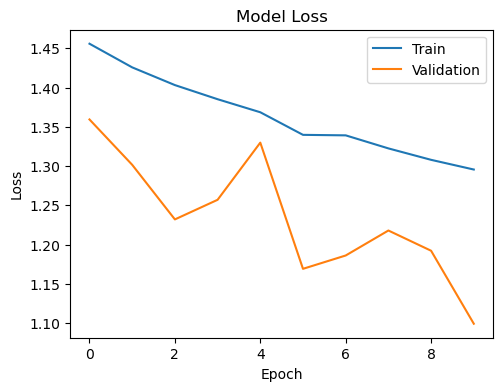

In [19]:
# Plot training and validation loss
plt.figure(figsize=(12, 4))

# Plot training & validation loss values
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper right')

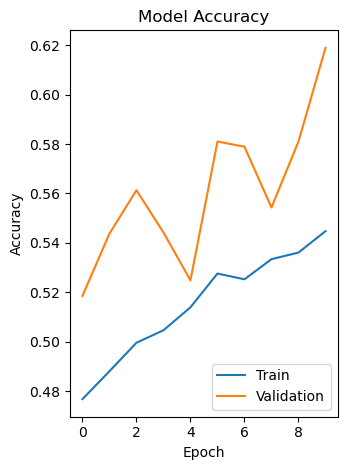

In [20]:
# Plot training & validation accuracy values
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='lower right')

plt.tight_layout()
plt.show()

In [21]:
# Save the entire model (architecture, weights, and training configuration) in an HDF5 file
model.save("complete_model.h5")

# Task 7

Select an image in the test set, plot it, show the prediction for it from your trained neural network, using model.predict.

The tutorial https://towardsdatascience.com/visualizing-intermediate-activation-in-convolutional-neural-networks-with-keras-260b36d60d0 

may be helpful.


Select a few more images. Comment on instances of misclassification.



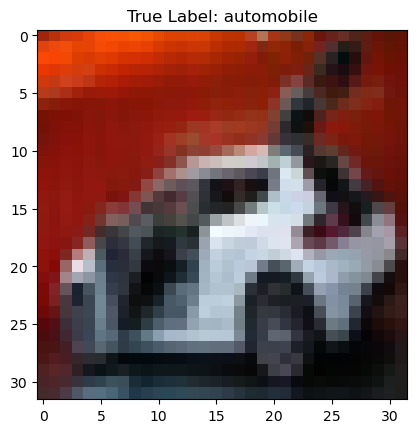

1/1 [==============================] - 0s 268ms/step


In [22]:
# Select an image from the test set
index = 6  # You can change this index to select a different image
test_image = np.expand_dims(test_images[index], axis=0)

# Plot the selected image
plt.imshow(test_images[index])
plt.title(f"True Label: {class_names[test_labels[index][0]]}")
plt.show()

# Use model.predict to get predictions
predictions = model.predict(test_image)


Predicted Label: automobile


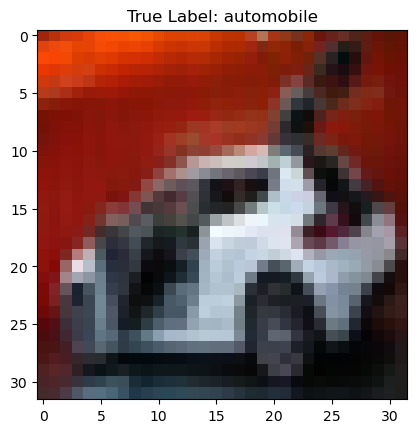

1/1 [==============================] - 0s 24ms/step
Example 1: True Label - cat, Predicted Label - cat


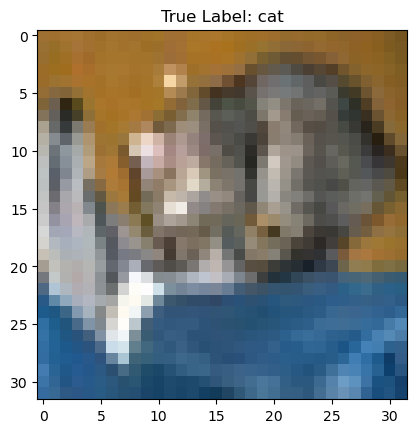


1/1 [==============================] - 0s 31ms/step
Example 2: True Label - ship, Predicted Label - ship


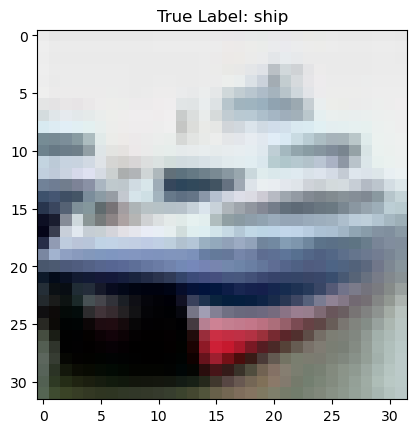


1/1 [==============================] - 0s 31ms/step
Example 3: True Label - ship, Predicted Label - ship


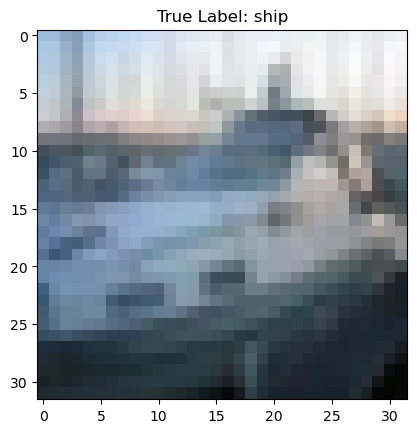


1/1 [==============================] - 0s 32ms/step
Example 4: True Label - airplane, Predicted Label - ship


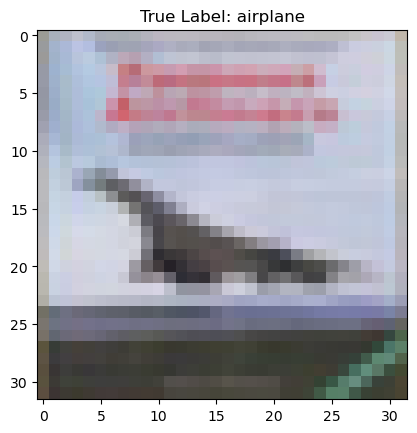

Misclassification!

1/1 [==============================] - 0s 32ms/step
Example 5: True Label - frog, Predicted Label - frog


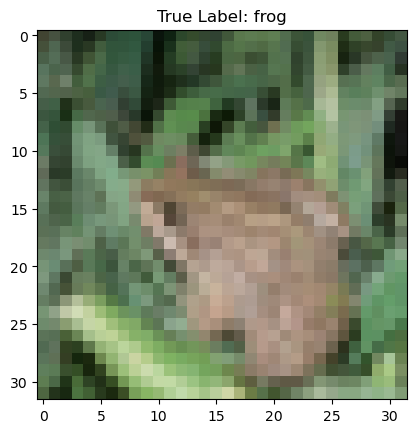

In [23]:
predicted_class = np.argmax(predictions[0])
predicted_class_name = class_names[predicted_class]

print(f"Predicted Label: {predicted_class_name}")

if predicted_class != test_labels[index][0]:
    print("Misclassification!")
    # Plot the selected image
plt.imshow(test_images[index])
plt.title(f"True Label: {class_names[test_labels[index][0]]}")
plt.show()

num_examples = 5
for i in range(num_examples):
    test_image = np.expand_dims(test_images[i], axis=0)
    true_label = class_names[test_labels[i][0]]
    
    predictions = model.predict(test_image)
    predicted_class = np.argmax(predictions[0])
    predicted_class_name = class_names[predicted_class]
    
    print(f"Example {i + 1}: True Label - {true_label}, Predicted Label - {predicted_class_name}")
    # Plot the selected image
    plt.imshow(test_images[i])
    plt.title(f"True Label: {class_names[test_labels[i][0]]}")
    plt.show()
    
    if predicted_class != test_labels[i][0]:
        print("Misclassification!")
    
    print()

# Task 8 (optional)
For a particular member of the test set, that you chose in Task 7, e.g. test_images[40] is the 40th image of the test set.

Plot a few feature maps and filters. You may adapt the code in 

https://towardsdatascience.com/visualizing-intermediate-activation-in-convolutional-neural-networks-with-keras-260b36d60d0

and 

https://machinelearningmastery.com/how-to-visualize-filters-and-feature-maps-in-convolutional-neural-networks/

In [24]:
layer_outputs = [layer.output for layer in model.layers[:12]] 
# Extracts the outputs of the top 12 layers

In [25]:
layer_outputs

[<KerasTensor: shape=(None, 30, 30, 32) dtype=float32 (created by layer 'conv2d')>,
 <KerasTensor: shape=(None, 15, 15, 32) dtype=float32 (created by layer 'max_pooling2d')>,
 <KerasTensor: shape=(None, 15, 15, 32) dtype=float32 (created by layer 'dropout')>,
 <KerasTensor: shape=(None, 13, 13, 64) dtype=float32 (created by layer 'conv2d_1')>,
 <KerasTensor: shape=(None, 6, 6, 64) dtype=float32 (created by layer 'max_pooling2d_1')>,
 <KerasTensor: shape=(None, 6, 6, 64) dtype=float32 (created by layer 'dropout_1')>,
 <KerasTensor: shape=(None, 4, 4, 64) dtype=float32 (created by layer 'conv2d_2')>,
 <KerasTensor: shape=(None, 1024) dtype=float32 (created by layer 'flatten')>,
 <KerasTensor: shape=(None, 1024) dtype=float32 (created by layer 'dropout_2')>,
 <KerasTensor: shape=(None, 64) dtype=float32 (created by layer 'dense')>,
 <KerasTensor: shape=(None, 64) dtype=float32 (created by layer 'dropout_3')>,
 <KerasTensor: shape=(None, 10) dtype=float32 (created by layer 'dense_1')>]

In [26]:
activation_model = models.Model(inputs=model.input, outputs=layer_outputs) 
# Creates a model that will return these outputs, given the model input

In [27]:
numtest = 40 #the same element of the test set that you chose for Task 7
imtest = np.expand_dims(test_images[numtest],axis=0)

In [28]:
activations = activation_model.predict(imtest)

1/1 [==============================] - 0s 94ms/step


# Task 9 (optional)

Plot a few feature maps and filters. You may adapt the code in 

https://towardsdatascience.com/visualizing-intermediate-activation-in-convolutional-neural-networks-with-keras-260b36d60d0

and 

https://machinelearningmastery.com/how-to-visualize-filters-and-feature-maps-in-convolutional-neural-networks/


In [29]:
layer_names = []
for layer in model.layers[:12]:
    layer_names.append(layer.name) # Names of the layers, so you can have them as part of your plot